# Pesquisa de Bem-Estar Auditivo de 2025
Insights sobre conscientização e potencial de adoção de soluções para saúde auditiva.

A Pesquisa de Bem-Estar Auditivo de 2025 coleta percepções, hábitos e conscientização do público em relação à saúde auditiva, com foco nos riscos crescentes do uso prolongado de fones de ouvido e fones de ouvido intra-auriculares. Realizada entre diversas faixas etárias, a pesquisa explora a valorização da audição, suas experiências com problemas auditivos e sua abertura a soluções digitais para o cuidado auditivo.

Este conjunto de dados fornece insights detalhados sobre:

🎯 Demografia – Distribuição por faixa etária dos entrevistados

🎧 Hábitos de escuta – Padrões diários de uso de fones de ouvido

⚠ Riscos auditivos – Incidência de desconforto, zumbido ou dor

🚧 Barreiras aos testes auditivos – Razões comuns pelas quais as pessoas evitam os testes

📱 Preparação digital – Interesse em um aplicativo móvel de saúde auditiva e disposição para pagar

💡 Preferências de recursos – Funções desejadas em um aplicativo de teste auditivo (por exemplo, testes rápidos, consultas médicas, personalização de som).

https://www.kaggle.com/datasets/adharshinikumar/2025-hearing-wellness-survey

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans

df_audi = pd.read_csv('Hearing well-being Survey Report.csv')

In [2]:
#Informações
df_audi.info()
df_audi.head()
df_audi.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 14 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Perceived_Hearing_Meaning                       387 non-null    object
 1   Hearing_FOMO                                    387 non-null    object
 2   Hearing_Test_Barrier                            385 non-null    object
 3   Missed_Important_Sounds                         387 non-null    object
 4   Left_Out_Due_To_Hearing                         387 non-null    object
 5   Daily_Headphone_Use                             387 non-null    object
 6   Belief_Early_Hearing_Care                       387 non-null    int64 
 7   Last_Hearing_Test_Method                        387 non-null    object
 8   Interest_in_Hearing_App                         387 non-null    object
 9   Desired_App_Features                            387 no

,Belief_Early_Hearing_Care
count,387.000000
mean,3.958656
std,1.266690
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [3]:
df_audi

,Perceived_Hearing_Meaning,Hearing_FOMO,Hearing_Test_Barrier,Missed_Important_Sounds,Left_Out_Due_To_Hearing,Daily_Headphone_Use,Belief_Early_Hearing_Care,Last_Hearing_Test_Method,Interest_in_Hearing_App,Desired_App_Features,Awareness_on_hearing_and_Willingness_to_invest,Paid_App_Test_Interest,Age_group,Ear_Discomfort_After_Use
0,"Staying independent and alert, Enjoying music,...",Sometimes,Cost,"Yes, in family conversations","Yes, often",My parent(s),5,"Self - application, Loved one, AI Support",Yes,"Privacy, Soft guidance, Visuals, Report sharin...",Yes,"Maybe, if it offers good value",18 - 24,No
1,"Staying independent and alert, Staying connect...",Rarely,Never felt the need,"Yes, in public spaces (trains, shops, announce...",Only in noisy places,My child/children,5,Self - application,Yes,Privacy,Yes,"No, I prefer getting tested at a hospital",18 - 24,Yes
2,"Staying independent and alert, I havenâ€™t tho...",Rarely,Shame,"Yes, during important work or school meetings",Sometimes,My parent(s),5,Self - application,Maybe,Soft guidance,No,"Yes, definitely",18 - 24,Maybe
3,Staying independent and alert,Yes often,Lack of awareness,"Yes, during important work or school meetings",Sometimes,1-2 hours,4,I've never taken a hearing test,"Yes, that would be helpful",Game-based interaction,Yes,"Yes, definitely",18 - 24,Occasionally
4,Staying independent and alert,Never,Lack of awareness,"No, I usually hear things well",Only in noisy places,Less than 1 hour,5,I've never taken a hearing test,"No, I don't think it's necessary","Quick tests, Game-based interaction, Detailed ...",No,"No, I prefer getting tested at a hospital",25 - 34,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,I havenâ€™t thought about it much,Rarely,Never thought about it,"Yes, in public spaces (trains, shops, announce...",Only in noisy places,1-2 hours,3,I've never taken a hearing test,"Maybe, if it's easy to use","Quick tests, Earphone calibration, Regular tes...",Yes,"Maybe, if it offers good value",18 - 24,Occasionally
383,Staying independent and alert,Yes often,I frequently testing by every six months,"Yes, during important work or school meetings","Yes, often",1-2 hours,5,At a hospital or clinic,"No, I don't think it's necessary","Quick tests, Regular testing reminders, Soft g...",Yes,"No, I prefer getting tested at a hospital",45 - 54,Yes
384,"Enjoying music, laughter, and life",Sometimes,Lack of awareness,"Yes, during important work or school meetings",Only in noisy places,1-2 hours,5,I've never taken a hearing test,"Maybe, if it's easy to use","Quick tests, Regular testing reminders, Soft g...",No,"No, I prefer getting tested at a hospital",18 - 24,Occasionally
385,I havenâ€™t thought about it much,Never,Lack of awareness,"No, I usually hear things well",Never,Less than 1 hour,5,At a hospital or clinic,"Maybe, if it's easy to use",Doctor consultation,No,"No, I prefer getting tested at a hospital",35 - 44,No


In [4]:
#Estatísticas descritivas para colunas numéricas
df_audi.describe(include='all')

,Perceived_Hearing_Meaning,Hearing_FOMO,Hearing_Test_Barrier,Missed_Important_Sounds,Left_Out_Due_To_Hearing,Daily_Headphone_Use,Belief_Early_Hearing_Care,Last_Hearing_Test_Method,Interest_in_Hearing_App,Desired_App_Features,Awareness_on_hearing_and_Willingness_to_invest,Paid_App_Test_Interest,Age_group,Ear_Discomfort_After_Use
count,387,387,385,387,387,387,387.000000,387,387,387,387,387,387,387
unique,25,4,48,8,5,6,NaN,6,5,205,2,3,6,5
top,Staying connected with the world,Sometimes,Lack of awareness,"No, I usually hear things well",Only in noisy places,Less than 1 hour,NaN,I've never taken a hearing test,"Maybe, if it's easy to use",Quick tests,Yes,"Maybe, if it offers good value",18 - 24,No
freq,78,148,234,142,131,148,NaN,307,177,34,284,195,287,142
mean,NaN,NaN,NaN,NaN,NaN,NaN,3.958656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.266690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#Valore Ausentes
df_audi.isna().sum()

Perceived_Hearing_Meaning                         0
Hearing_FOMO                                      0
Hearing_Test_Barrier                              2
Missed_Important_Sounds                           0
Left_Out_Due_To_Hearing                           0
Daily_Headphone_Use                               0
Belief_Early_Hearing_Care                         0
Last_Hearing_Test_Method                          0
Interest_in_Hearing_App                           0
Desired_App_Features                              0
Awareness_on_hearing_and_Willingness_to_invest    0
Paid_App_Test_Interest                            0
Age_group                                         0
Ear_Discomfort_After_Use                          0
dtype: int64

In [28]:
moda_barreira = df_audi['Hearing_Test_Barrier'].mode()[0]
df_audi['Hearing_Test_Barrier'].fillna(moda_barreira, inplace=True)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\2943240968.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_audi['Hearing_Test_Barrier'].fillna(moda_barreira, inplace=True)


C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\4168967663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')


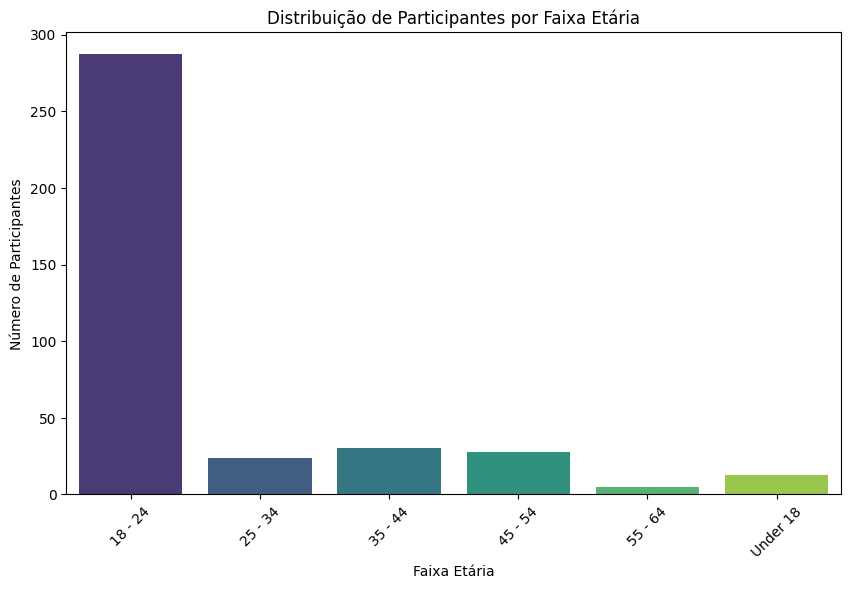

In [6]:
#Frequência de cada faixa etária
age_counts = df_audi['Age_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')
plt.title('Distribuição de Participantes por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.show()

A grande maioria dos participantes do estudo pertence à faixa etária de 18 a 24 anos, com um número de participantes muito superior a todas as outras faixas etárias.
As conclusões do estudo podem ter um viés demográfico, refletindo principalmente as experiências, hábitos e opiniões de um público jovem adulto. Portanto, pode não ser representativo da população em geral, especialmente de grupos mais velhos.

In [7]:
#Exibindo a contagem
print("Contagem de participantes por faixa etária:")
print(age_counts)

Contagem de participantes por faixa etária:
Age_group
18 - 24     287
25 - 34      24
35 - 44      30
45 - 54      28
55 - 64       5
Under 18     13
Name: count, dtype: int64


In [8]:
#Tabela cruzada entre 'Age_group' e 'Daily_Headphone_Use'
headphone_age_crosstab = pd.crosstab(df_audi['Age_group'], df_audi['Daily_Headphone_Use'])

print("Tabela Cruzada: Uso Diário de Fones de Ouvido por Faixa Etária")
print(headphone_age_crosstab)

Tabela Cruzada: Uso Diário de Fones de Ouvido por Faixa Etária
Daily_Headphone_Use  1-2 hours  2-4 hours  Less than 1 hour  \
Age_group                                                     
18 - 24                     94         72                80   
25 - 34                      7          1                14   
35 - 44                      4          1                25   
45 - 54                      4          2                21   
55 - 64                      1          0                 4   
Under 18                     3          3                 4   

Daily_Headphone_Use  More than 4 hours  My child/children  My parent(s)  
Age_group                                                                
18 - 24                             38                  1             2  
25 - 34                              2                  0             0  
35 - 44                              0                  0             0  
45 - 54                              1                  0     

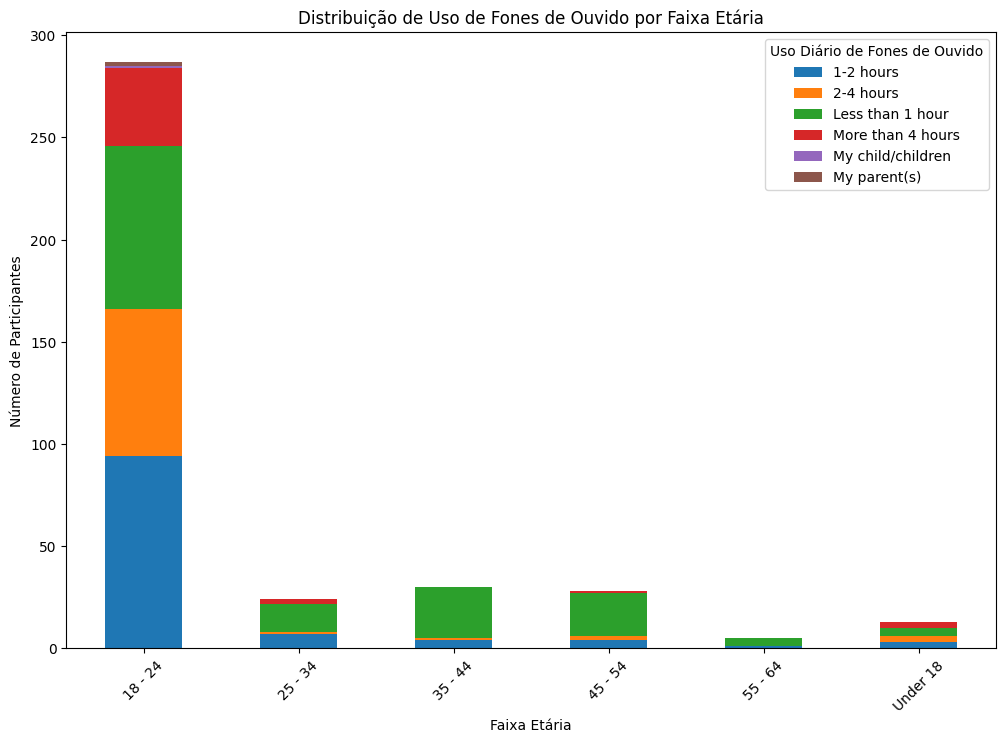

In [9]:
headphone_age_crosstab.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Distribuição de Uso de Fones de Ouvido por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Uso Diário de Fones de Ouvido')
plt.show()

O uso de fones de ouvido é predominantemente um hábito da população mais jovem, especialmente entre os 18 e 24 anos, e que este comportamento de uso diminui de forma acentuada com o aumento da idade.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\2009190211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=barrier_counts.values, y=barrier_counts.index, palette='viridis')
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 143 (\x8f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


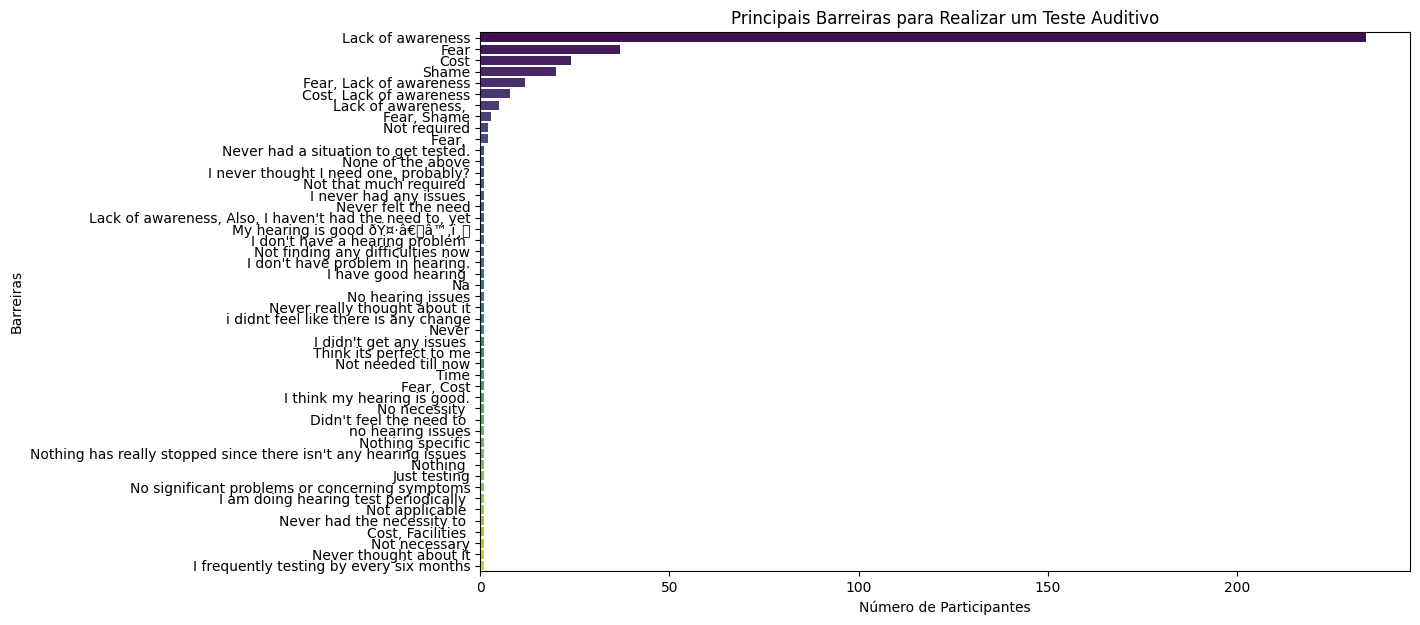

In [10]:
#Frequência de cada barreira
barrier_counts = df_audi['Hearing_Test_Barrier'].value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=barrier_counts.values, y=barrier_counts.index, palette='viridis')
plt.title('Principais Barreiras para Realizar um Teste Auditivo')
plt.xlabel('Número de Participantes')
plt.ylabel('Barreiras')
plt.show()

Qualquer estratégia para aumentar a realização de testes de audição deve focar massivamente em educação e conscientização. Resolver o medo e o custo são importantes, mas não são as principais razões pelas quais a maioria das pessoas não faz um teste.

In [11]:
#Contagem exata
print("Contagem de participantes por barreira:")
print(barrier_counts)

Contagem de participantes por barreira:
Hearing_Test_Barrier
Lack of awareness                                                   234
Fear                                                                 37
Cost                                                                 24
Shame                                                                20
Fear, Lack of awareness                                              12
Cost, Lack of awareness                                               8
Lack of awareness,                                                    5
Fear, Shame                                                           3
Not required                                                          2
Fear,                                                                 2
Never had a situation to get tested.                                  1
None of the above                                                     1
I never thought I need one, probably?                                 1
Not

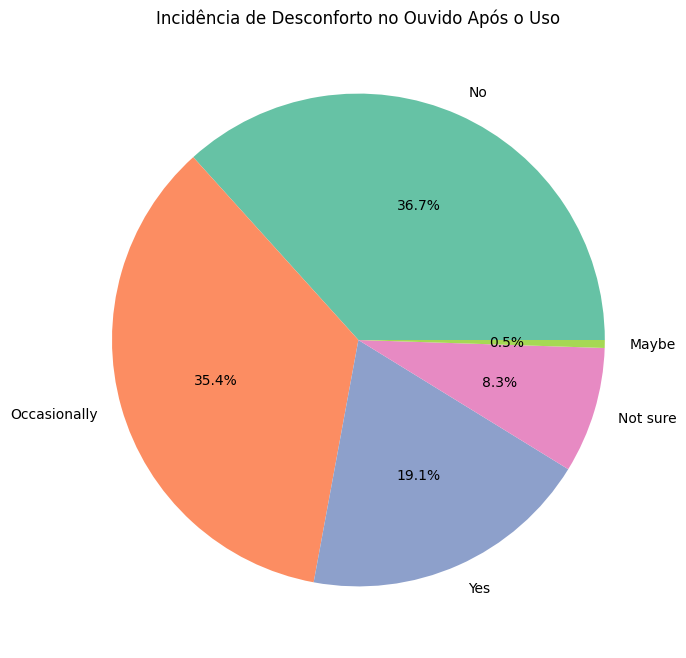

In [12]:
#Frequência de cada resposta
discomfort_counts = df_audi['Ear_Discomfort_After_Use'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(discomfort_counts, labels=discomfort_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Incidência de Desconforto no Ouvido Após o Uso')
plt.show()

A maioria das pessoas não tem um problema constante de desconforto, mas uma grande parcela (quase 55% se somarmos "ocasionalmente" e "sim") experimenta desconforto em algum nível. Isso indica que o problema é significativo e merece atenção.

In [13]:
#Contagem 
print("Contagem de participantes que sentem desconforto no ouvido:")
print(discomfort_counts)

Contagem de participantes que sentem desconforto no ouvido:
Ear_Discomfort_After_Use
No              142
Occasionally    137
Yes              74
Not sure         32
Maybe             2
Name: count, dtype: int64


In [14]:
#Tabela cruzada para ver a relação entre uso e desconforto
crosstab_use_discomfort = pd.crosstab(df_audi['Daily_Headphone_Use'], df_audi['Ear_Discomfort_After_Use'], normalize='index') * 100

print("Relação entre Uso de Fones e Desconforto (%):")
print(crosstab_use_discomfort)

Relação entre Uso de Fones e Desconforto (%):
Ear_Discomfort_After_Use      Maybe         No   Not sure  Occasionally  \
Daily_Headphone_Use                                                       
1-2 hours                  0.000000  35.398230  11.504425     39.823009   
2-4 hours                  1.265823  21.518987  10.126582     44.303797   
Less than 1 hour           0.000000  47.297297   4.729730     27.702703   
More than 4 hours          0.000000  31.818182   9.090909     36.363636   
My child/children          0.000000   0.000000   0.000000      0.000000   
My parent(s)              50.000000  50.000000   0.000000      0.000000   

Ear_Discomfort_After_Use         Yes  
Daily_Headphone_Use                   
1-2 hours                  13.274336  
2-4 hours                  22.784810  
Less than 1 hour           20.270270  
More than 4 hours          22.727273  
My child/children         100.000000  
My parent(s)                0.000000  


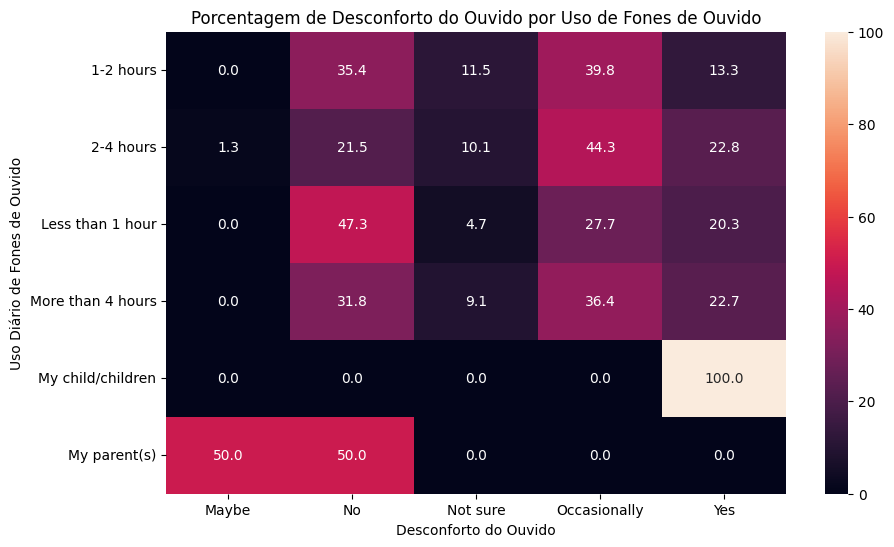

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_use_discomfort, annot=True, cmap='rocket', fmt='.1f')
plt.title('Porcentagem de Desconforto do Ouvido por Uso de Fones de Ouvido')
plt.xlabel('Desconforto do Ouvido')
plt.ylabel('Uso Diário de Fones de Ouvido')
plt.show()

Mostra a porcentagem de desconforto no ouvido em relação ao tempo de uso diário de fones de ouvido.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\2633263951.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interest_counts.index, y=interest_counts.values, palette='viridis')


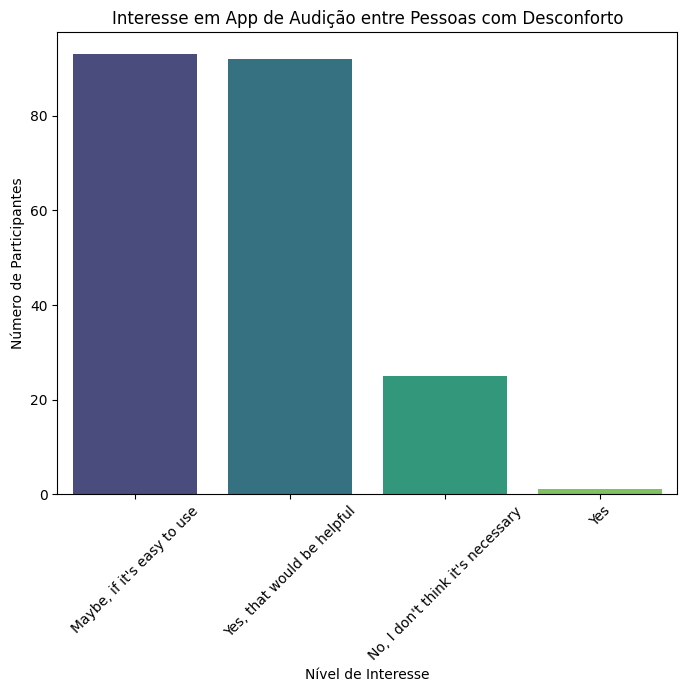

In [16]:
#Pessoas que sentem desconforto
df_discomfort = df_audi[df_audi['Ear_Discomfort_After_Use'].isin(['Yes', 'Occasionally'])]

#Contando o interesse em aplicativos dentro desse grupo
interest_counts = df_discomfort['Interest_in_Hearing_App'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=interest_counts.index, y=interest_counts.values, palette='viridis')
plt.title('Interesse em App de Audição entre Pessoas com Desconforto')
plt.xlabel('Nível de Interesse')
plt.ylabel('Número de Participantes')
plt.xticks(rotation=45)
plt.show()

Para um aplicativo de audição ser bem-sucedido entre usuários que já experimentam desconforto, ele deve focar em ser extremamente fácil de usar. A utilidade é valorizada, mas a barreira de entrada da complexidade é a maior preocupação para este público.

In [17]:
#Contagem
print("Interesse em aplicativos entre quem sente desconforto:")
print(interest_counts)

Interesse em aplicativos entre quem sente desconforto:
Interest_in_Hearing_App
Maybe, if it's easy to use          93
Yes, that would be helpful          92
No, I don't think it's necessary    25
Yes                                  1
Name: count, dtype: int64


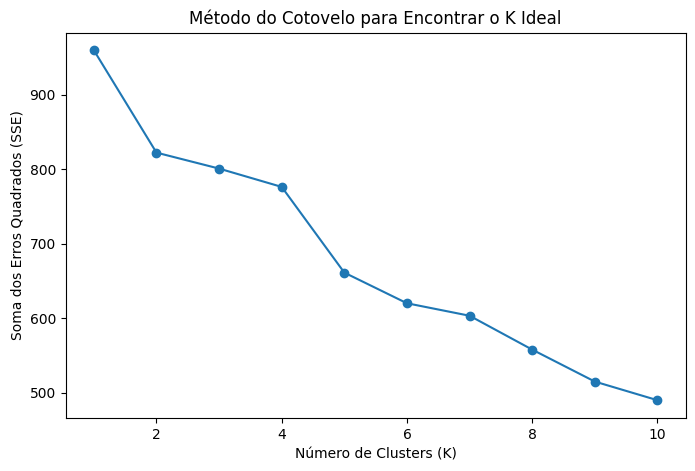

In [18]:
#ML
df_ml = df_audi[['Age_group', 'Daily_Headphone_Use', 'Ear_Discomfort_After_Use', 'Interest_in_Hearing_App']]

df_encoded = pd.get_dummies(df_ml, columns=['Age_group', 'Daily_Headphone_Use', 'Ear_Discomfort_After_Use', 'Interest_in_Hearing_App'])

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_encoded)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Método do Cotovelo para Encontrar o K Ideal')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Soma dos Erros Quadrados (SSE)')
plt.show()


O ponto onde a queda da SSE começa a se achatar, ocorre em K=4. Um bom equilíbrio entre a redução da variabilidade dos dados e a complexidade do modelo, tornando-se o ponto de maior eficiência.

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_audi['Cluster'] = kmeans.fit_predict(df_encoded)

#Análise dos clusters
for i in range(3):
    print(f"Cluster {i}")
    print(df_audi[df_audi['Cluster'] == i].describe(include='all'))

Cluster 0
               Perceived_Hearing_Meaning Hearing_FOMO Hearing_Test_Barrier  \
count                                 89           89                   89   
unique                                17            4                   22   
top     Staying connected with the world        Never    Lack of awareness   
freq                                  29           37                   53   
mean                                 NaN          NaN                  NaN   
std                                  NaN          NaN                  NaN   
min                                  NaN          NaN                  NaN   
25%                                  NaN          NaN                  NaN   
50%                                  NaN          NaN                  NaN   
75%                                  NaN          NaN                  NaN   
max                                  NaN          NaN                  NaN   

               Missed_Important_Sounds Left_Out_Due_T

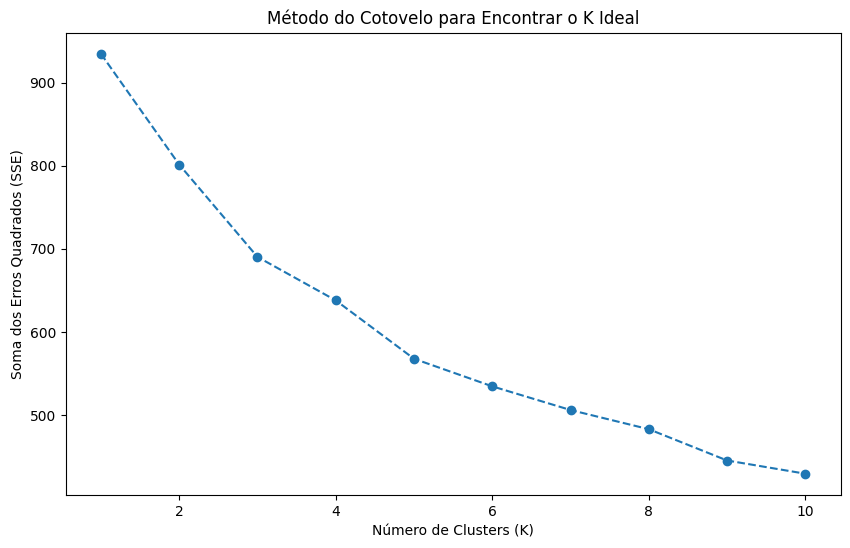

In [20]:
df_ml = df_audi[['Daily_Headphone_Use', 'Ear_Discomfort_After_Use', 'Age_group', 'Paid_App_Test_Interest', 'Interest_in_Hearing_App']]

df_encoded = pd.get_dummies(df_ml, drop_first=True)

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_encoded)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Método do Cotovelo para Encontrar o K Ideal')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Soma dos Erros Quadrados (SSE)')
plt.show()

O valor ideal de K para este conjunto de dados é 3. Isso significa que os dados podem ser melhor agrupados em três clusters distintos para uma análise mais precisa.

In [21]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
df_audi['Cluster'] = kmeans.fit_predict(df_encoded)

for i in range(num_clusters):
    cluster_df = df_audi[df_audi['Cluster'] == i]
    print(f"Análise do Cluster {i} (n={len(cluster_df)})")
    
    print("Distribuição de Faixa Etária:")
    print(cluster_df['Age_group'].value_counts(normalize=True).round(2))
    
    print("Uso Diário de Fones de Ouvido:")
    print(cluster_df['Daily_Headphone_Use'].value_counts(normalize=True).round(2))
    
    print("Desconforto no Ouvido:")
    print(cluster_df['Ear_Discomfort_After_Use'].value_counts(normalize=True).round(2))
    
    print("Interesse em Aplicativo:")
    print(cluster_df['Interest_in_Hearing_App'].value_counts(normalize=True).round(2))

Análise do Cluster 0 (n=113)
Distribuição de Faixa Etária:
Age_group
18 - 24     0.82
25 - 34     0.04
45 - 54     0.04
35 - 44     0.04
Under 18    0.04
55 - 64     0.01
Name: proportion, dtype: float64
Uso Diário de Fones de Ouvido:
Daily_Headphone_Use
1-2 hours            0.37
2-4 hours            0.29
Less than 1 hour     0.23
More than 4 hours    0.11
Name: proportion, dtype: float64
Desconforto no Ouvido:
Ear_Discomfort_After_Use
Occasionally    0.68
Yes             0.17
Not sure        0.14
Maybe           0.01
Name: proportion, dtype: float64
Interesse em Aplicativo:
Interest_in_Hearing_App
Maybe, if it's easy to use          0.91
No, I don't think it's necessary    0.09
Name: proportion, dtype: float64
Análise do Cluster 1 (n=147)
Distribuição de Faixa Etária:
Age_group
18 - 24     0.64
45 - 54     0.13
25 - 34     0.10
35 - 44     0.08
Under 18    0.03
55 - 64     0.01
Name: proportion, dtype: float64
Uso Diário de Fones de Ouvido:
Daily_Headphone_Use
Less than 1 hour     0.5

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\1887801344.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_counts.values, y=feature_counts.index, palette='crest')


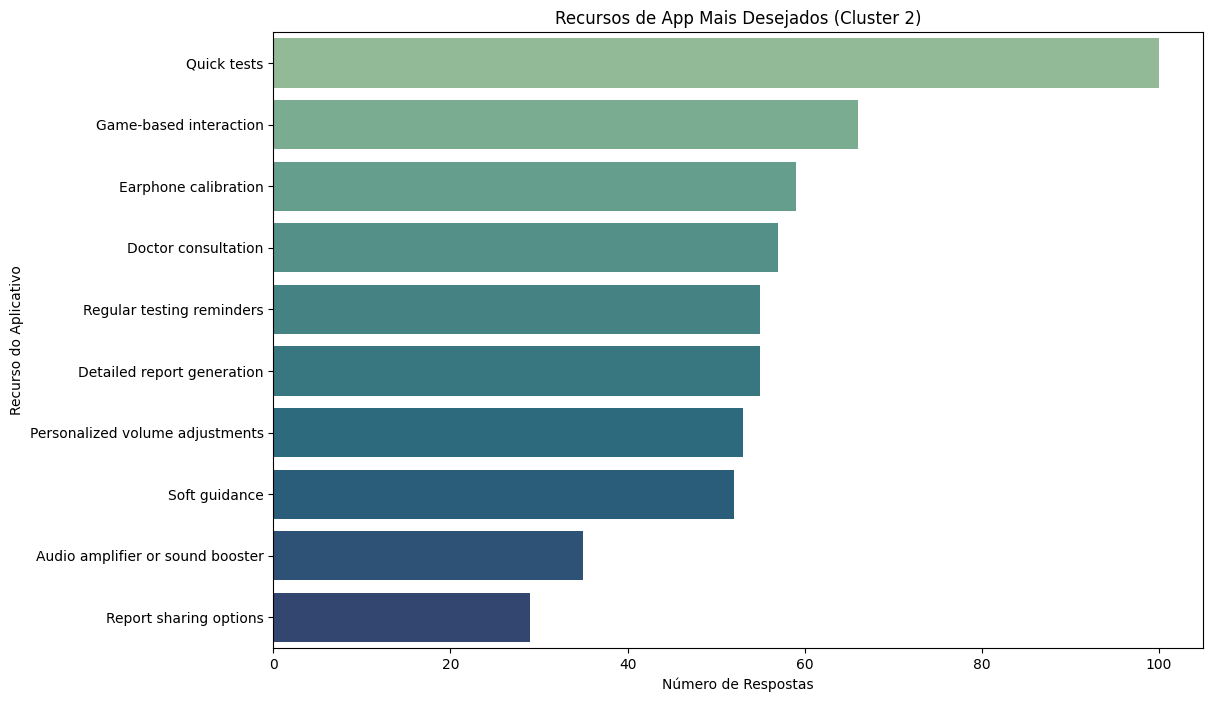

Contagem de recursos de aplicativo mais desejados no Cluster 2:
Quick tests                         100
Game-based interaction               66
Earphone calibration                 59
Doctor consultation                  57
Regular testing reminders            55
Detailed report generation           55
Personalized volume adjustments      53
Soft guidance                        52
Audio amplifier or sound booster     35
Report sharing options               29
dtype: int64


In [22]:
df_cluster2 = df_audi[df_audi['Cluster'] == 2]

#Analisar os recursos de app desejados dentro deste cluster
desired_features = df_cluster2['Desired_App_Features'].str.get_dummies(sep=', ')
feature_counts = desired_features.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_counts.values, y=feature_counts.index, palette='crest')
plt.title('Recursos de App Mais Desejados (Cluster 2)')
plt.xlabel('Número de Respostas')
plt.ylabel('Recurso do Aplicativo')
plt.show()

print("Contagem de recursos de aplicativo mais desejados no Cluster 2:")
print(feature_counts)

Valoriza a rapidez, a interatividade e a praticidade em um aplicativo, buscando soluções que se integrem facilmente à sua rotina e que sejam úteis de forma imediata.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\2858353075.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=barrier_counts_cluster2.values, y=barrier_counts_cluster2.index, palette='mako')


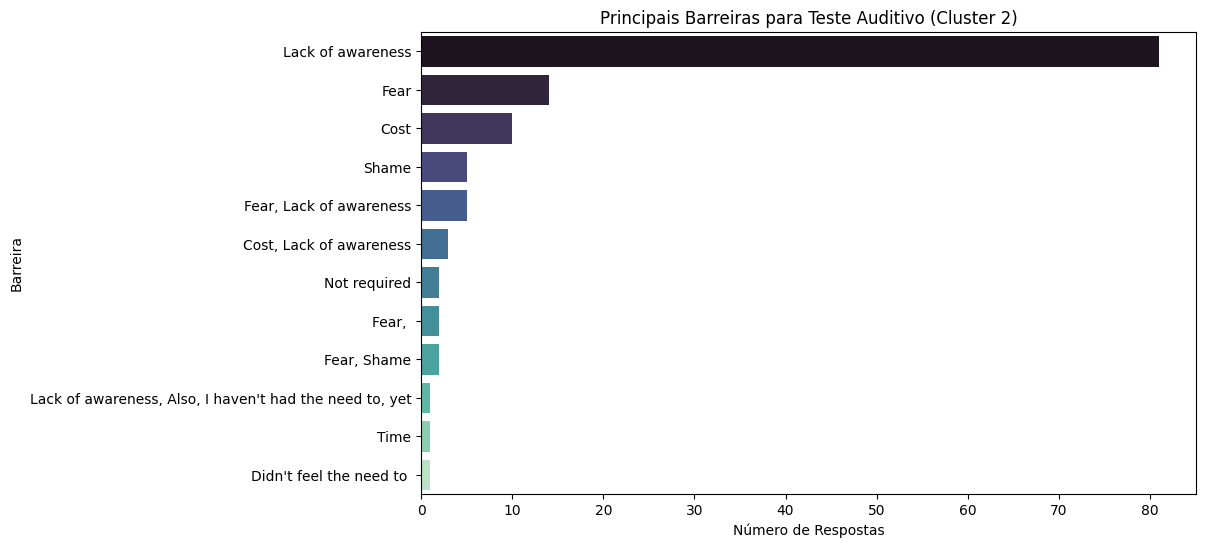

Contagem de barreiras para teste auditivo no Cluster 2:
Hearing_Test_Barrier
Lack of awareness                                          81
Fear                                                       14
Cost                                                       10
Shame                                                       5
Fear, Lack of awareness                                     5
Cost, Lack of awareness                                     3
Not required                                                2
Fear,                                                       2
Fear, Shame                                                 2
Lack of awareness, Also, I haven't had the need to, yet     1
Time                                                        1
Didn't feel the need to                                     1
Name: count, dtype: int64


In [23]:
#Teste auditivo no Cluster 2
barrier_counts_cluster2 = df_cluster2['Hearing_Test_Barrier'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=barrier_counts_cluster2.values, y=barrier_counts_cluster2.index, palette='mako')
plt.title('Principais Barreiras para Teste Auditivo (Cluster 2)')
plt.xlabel('Número de Respostas')
plt.ylabel('Barreira')
plt.show()

print("Contagem de barreiras para teste auditivo no Cluster 2:")
print(barrier_counts_cluster2)

O Cluster 2, a principal estratégia para incentivar testes de audição seria uma campanha de conscientização que eduque as pessoas sobre a importância e os benefícios de testar a audição. Superar o medo, o custo e a vergonha seriam ações secundárias, mas ainda relevantes.

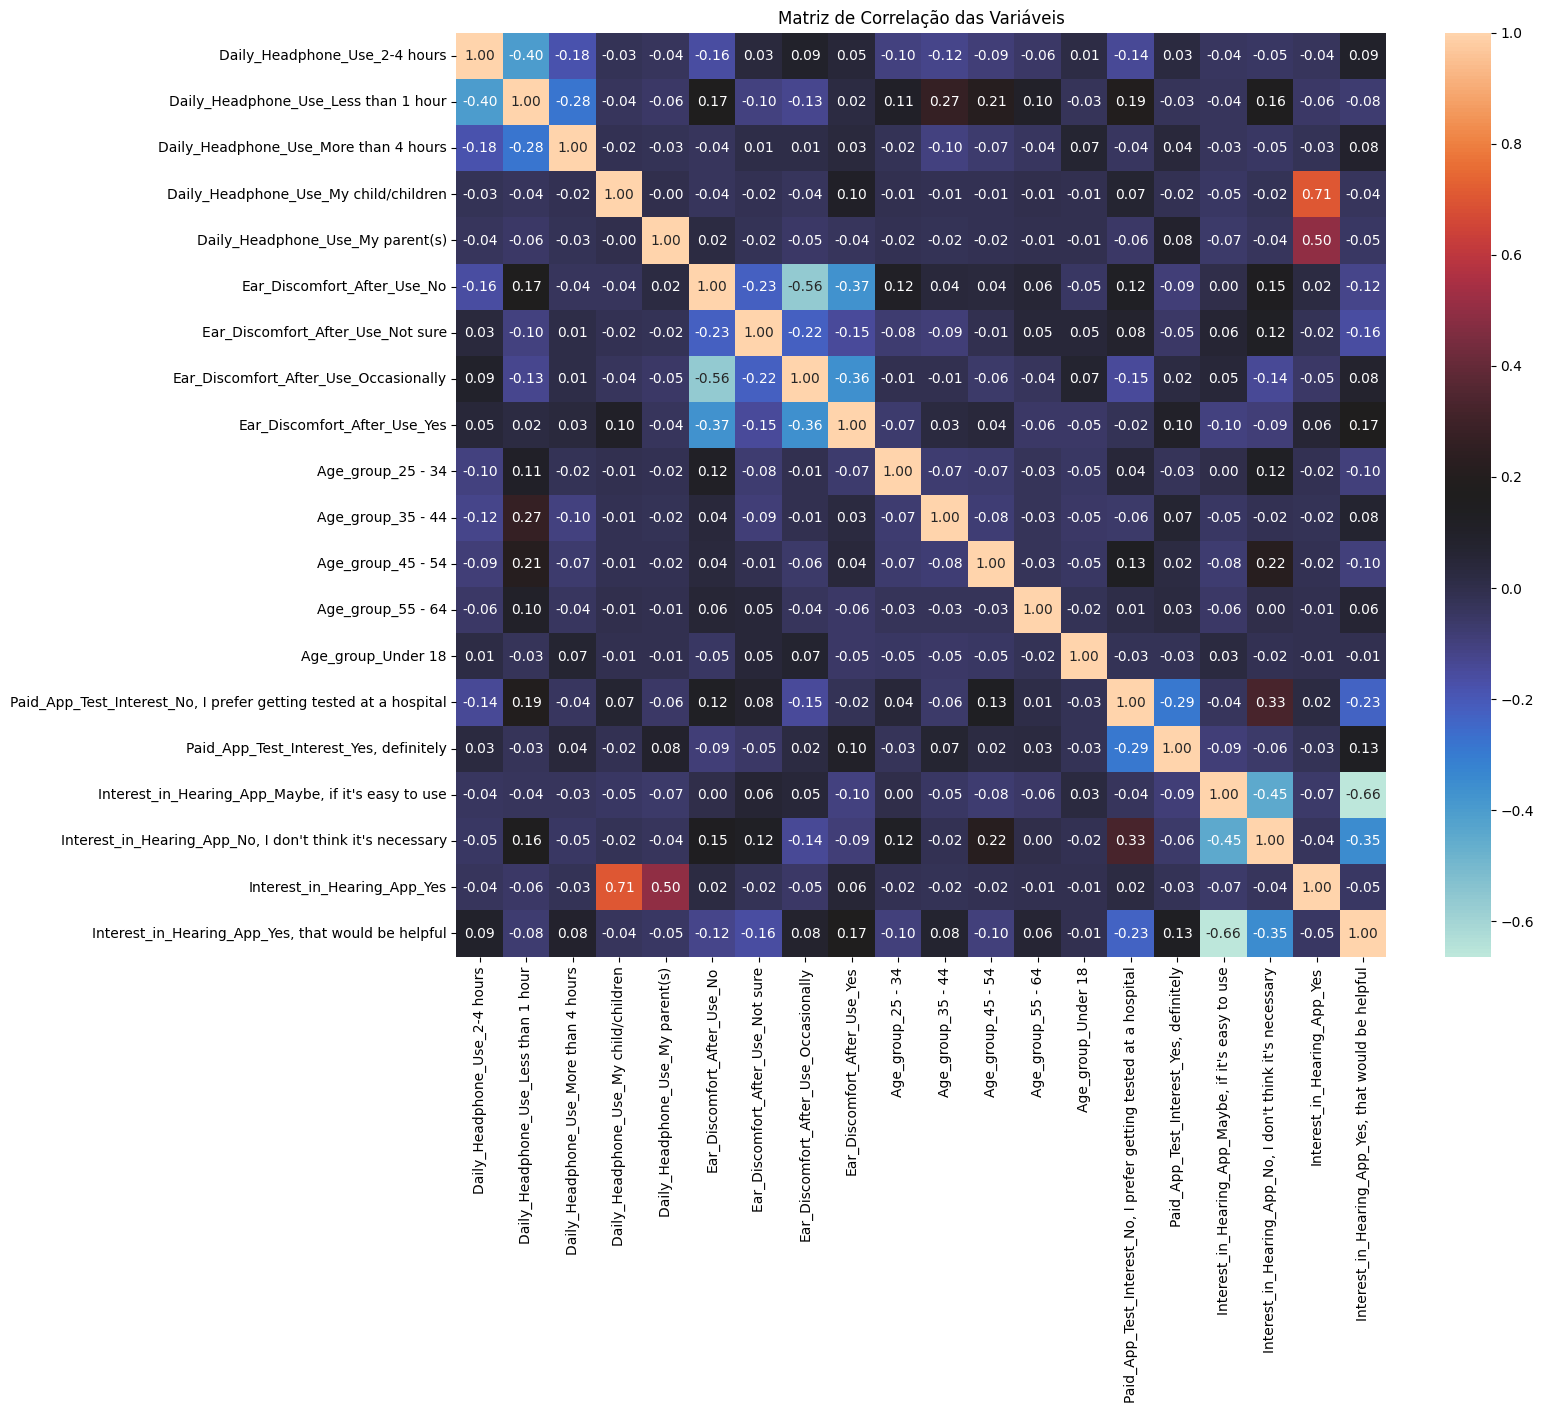

In [24]:
plt.figure(figsize=(15, 12))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='icefire')
plt.title('Matriz de Correlação das Variáveis')
plt.show()

O uso prolongado de fones de ouvido e a idade são os fatores que mais se correlacionam com o desconforto auditivo e o interesse em aplicativos de teste de audição.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [26]:
#Simplificar a variável de desconforto para Sim/Não
df_audi['target'] = df_audi['Ear_Discomfort_After_Use'].apply(lambda x: 'Sim' if x in ['Yes', 'Occasionally'] else 'Não')

features = ['Age_group', 'Daily_Headphone_Use', 'Hearing_Test_Barrier', 'Perceived_Hearing_Meaning']
target = 'target'

df_encoded = pd.get_dummies(df_audi[features], drop_first=True)
df_encoded[target] = df_audi[target]

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia do Modelo: {accuracy:.2f}")
print("Relatório de Classificação:")
print(report)

Acurácia do Modelo: 0.54
Relatório de Classificação:
              precision    recall  f1-score   support

         Não       0.52      0.46      0.49        37
         Sim       0.56      0.61      0.58        41

    accuracy                           0.54        78
   macro avg       0.54      0.53      0.53        78
weighted avg       0.54      0.54      0.54        78



C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\2851083038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 143 (\x8f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


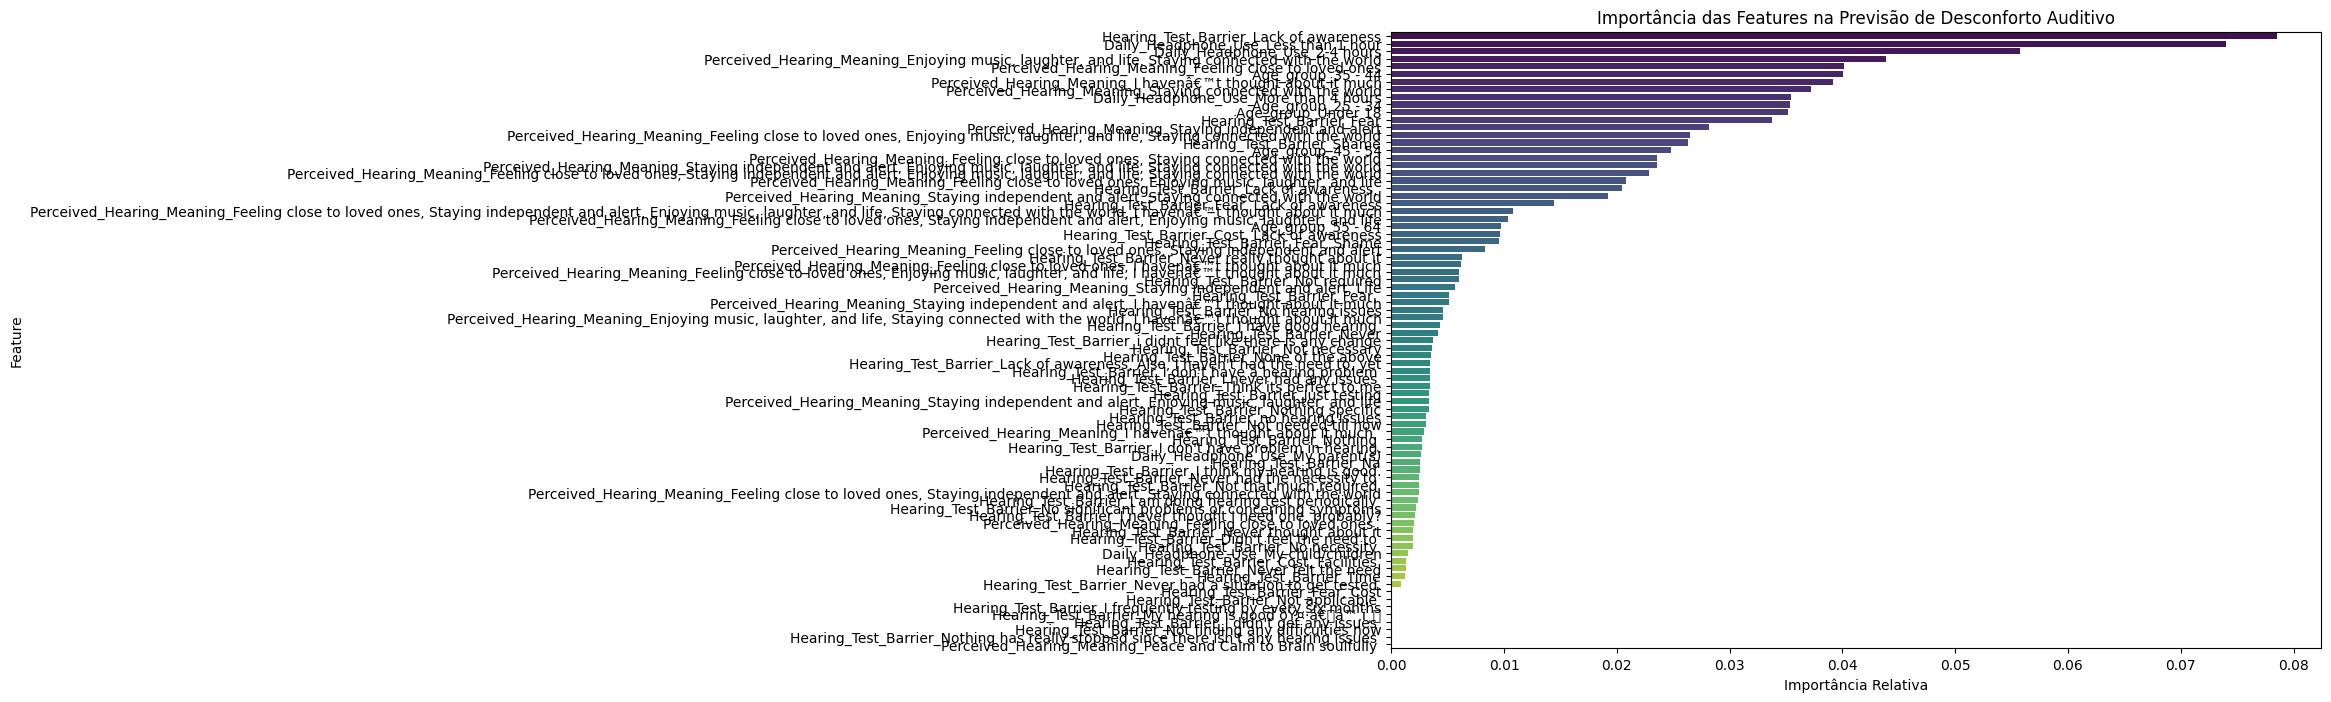

In [27]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Importância das Features na Previsão de Desconforto Auditivo')
plt.xlabel('Importância Relativa')
plt.ylabel('Feature')
plt.show()

A previsão do desconforto auditivo são aquelas relacionadas à Percepção e Significado (Perceived_Meaning). Elas englobam sentimentos como "sentir-se próximo de pessoas amadas," "sentir-se independente," "desfrutar de música" e "sentir-se calmo." Isso sugere que a percepção emocional e o impacto psicológico do som são mais importantes do que os dados brutos do teste de audição (Hearing_Test_Barrier).
A percepção e o significado que um indivíduo atribui aos sons, especialmente no contexto de sua vida pessoal e bem-estar, são os fatores mais cruciais para a previsão do desconforto auditivo, superando a importância dos resultados de testes de audição convencionais.

# **Conclusão**

# Problema de Mercado
Os dados confirmou que o uso prolongado de fones de ouvido está associado a desconfortos auditivos. A pesquisa identificou que um percentual significativo de pessoas, especialmente entre 18 e 24 anos, relata desconforto frequentemente, indicando uma necessidade real e não atendida.

# Público-Alvo 
A análise de cluster foi essencial para segmentar a base de respondentes e identificar o perfil ideal do cliente. O Cluster 2, apelidado de "Os Preocupados", se destaca por seu alto uso de fones, desconforto recorrente e, crucialmente, um forte interesse em soluções digitais para o problema.

# Foco no Cliente
As preferências do Cluster 2 mostrou que a solução ideal não é um simples teste, mas uma ferramenta com recursos práticos e proativos. Recursos como monitoramento de volume em tempo real, testes rápidos e calibração de fones são os mais desejados, alinhando o produto às necessidades do público.

# Estratégia de Marketing
O tempo diário de uso de fones de ouvido é o fator mais preditivo de desconforto. Isso otimiza a estratégia, permitindo que as campanhas de marketing sejam direcionadas com precisão para usuários com esse comportamento de alto risco, aumentando a eficácia e o retorno sobre o investimento.

A pesquisa não apenas confirma que existe um problema crescente de saúde auditiva, mas também fornece um guia estratégico completo para o desenvolvimento de um produto. Ao focar no público de "Os Preocupados", oferecendo os recursos que eles mais valorizam e utilizando a análise preditiva para otimizar a aquisição de clientes, a solução digital tem um alto potencial de sucesso.
Indicando que a criação de um aplicativo para a saúde auditiva é uma oportunidade de negócio viável e promissora.


# **Nathália Sorg**